In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/binaryclassificationwithabankchurndataset/sample_submission.csv
/kaggle/input/competitions/binaryclassificationwithabankchurndataset/train.csv
/kaggle/input/competitions/binaryclassificationwithabankchurndataset/test.csv


In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/kaggle/input/competitions/binaryclassificationwithabankchurndataset/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/binaryclassificationwithabankchurndataset/test.csv')

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("\nUstunlar turlari:")
print(train_df.dtypes)

Train: (15000, 14)
Test: (10000, 13)

Ustunlar turlari:
id                   int64
CustomerId         float64
Surname             object
CreditScore        float64
Geography           object
Gender              object
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited             float64
dtype: object


In [12]:
train_df.head(50)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.00,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.00,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.00,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.00,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.00,2.0,1.0,0.0,158958.90,0.0
5,5,15694192.0,Macleod,627.0,France,Female,43.0,7.0,125977.81,2.0,1.0,1.0,52367.29,0.0
6,6,15797165.0,Chukwuebuka,600.0,France,Female,37.0,3.0,0.00,2.0,0.0,0.0,107964.36,0.0
7,7,15590011.0,Tuan,579.0,France,Male,21.0,2.0,0.00,2.0,1.0,1.0,151401.33,0.0
8,8,15659327.0,Tien,614.0,France,Male,40.0,6.0,0.00,2.0,1.0,0.0,158816.03,0.0
9,9,15594864.0,Chukwuemeka,482.0,Spain,Male,33.0,6.0,0.00,1.0,0.0,1.0,132770.15,0.0


CustomerId: Mijozning bankdagi unikal ID raqami.

Surname: Mijozning familiyasi (Matnli/Object ustun).

CreditScore: Mijozning kredit reytingi (baxosi). Bu raqam qanchalik yuqori bo'lsa, mijoz bank uchun shunchalik ishonchli hisoblanadi.

Geography: Mijoz yashaydigan davlat (Jadvalda France, Spain, Germany kabi davlatlar ko'rinyapti).

Gender: Mijozning jinsi (Male - erkak, Female - ayol).

Age: Mijozning yoshi.

Tenure: Mijoz necha yildan beri shu bank xizmatlaridan foydalanib kelayotganligi.

Balance: Mijozning bank hisob raqamidagi pul miqdori (balansi). Ko'ryapsizmi, ko'pchilikda 0.0 turibdi, demak hisobida puli yo'q mijozlar ham ko'p.

NumOfProducts: Mijoz bankning nechta mahsulotidan foydalanadi (masalan: plastik karta, kredit, omonat va h.k.). Jadvalda 1.0, 2.0 kabi qiymatlar bor.

HasCrCard: Mijozda kredit karta bormi yoki yo'qmi (1.0 - bor, 0.0 - yo'q).

IsActiveMember: Mijoz bankda faolmi yoki yo'qmi (1.0 - faol, 0.0 - nofaol).

EstimatedSalary: Mijozning taxminiy oylik yoki yillik daromadi (maoshi).

Exited (Target/Maqsadli ustun): Eng asosiysi! Mijoz bankdan ketganmi yoki yo'qmi:

0.0 — Mijoz bankda qolgan ( sodiq mijoz).

1.0 — Mijoz bankni tark etgan (yoki qarzni qaytara olmay chiqib ketgan).

In [13]:
print("Train to'plamidagi bo'sh kataklar soni:")
print(train_df.isnull().sum())

print("\nTest to'plamidagi bo'sh kataklar soni:")
print(test_df.isnull().sum())

Train to'plamidagi bo'sh kataklar soni:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Test to'plamidagi bo'sh kataklar soni:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


Exited ustuni taqsimoti:
Exited
0.0    12023
1.0     2977
Name: count, dtype: int64


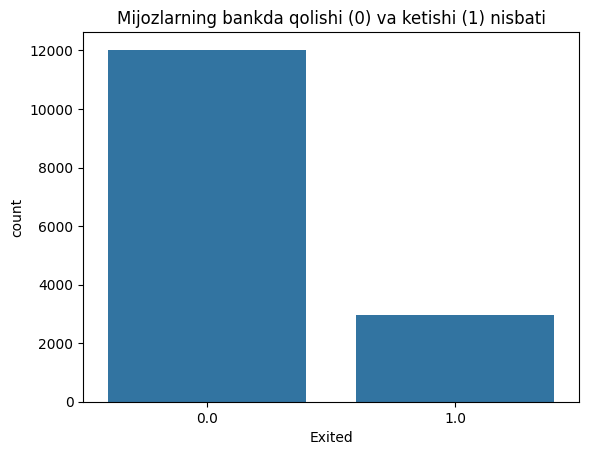

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ketganlar va qolganlar sonini aniqlaymiz
print("Exited ustuni taqsimoti:")
print(train_df['Exited'].value_counts())

# Grafik ko'rinishida chizamiz
sns.countplot(x='Exited', data=train_df)
plt.title('Mijozlarning bankda qolishi (0) va ketishi (1) nisbati')
plt.show()

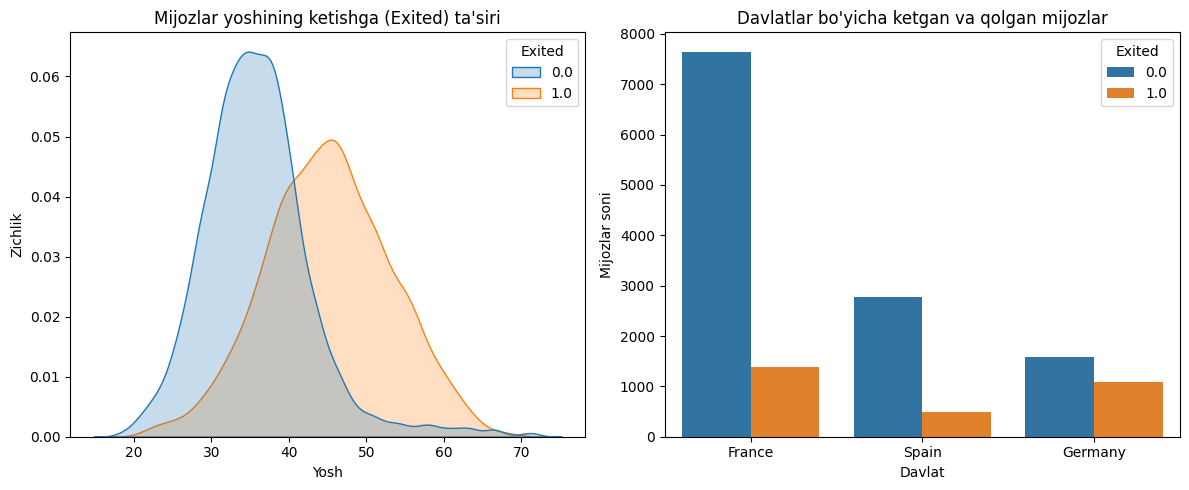

In [19]:
# 1-Grafik: Yoshning mijozlar ketishiga ta'siri (KDE plot - zichlik grafigi)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=train_df, x='Age', hue='Exited', fill=True, common_norm=False)
plt.title('Mijozlar yoshining ketishga (Exited) ta\'siri')
plt.xlabel('Yosh')
plt.ylabel('Zichlik')

# 2-Grafik: Davlatlarning mijozlar ketishiga ta'siri
plt.subplot(1, 2, 2)
sns.countplot(data=train_df, x='Geography', hue='Exited')
plt.title('Davlatlar bo\'yicha ketgan va qolgan mijozlar')
plt.xlabel('Davlat')
plt.ylabel('Mijozlar soni')

plt.tight_layout()
plt.show()

In [20]:
print("Train to'plamidagi davlatlar va ularning soni:")
print(train_df['Geography'].value_counts())

print("\nGender ustunidagi qiymatlar soni:")
print(train_df['Gender'].value_counts())

Train to'plamidagi davlatlar va ularning soni:
Geography
France     9040
Spain      3280
Germany    2680
Name: count, dtype: int64

Gender ustunidagi qiymatlar soni:
Gender
Male      8478
Female    6522
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import LabelEncoder

# 1. Gender ustunini to'g'ridan-to'g'ri 0 va 1 ga o'tkazamiz (Male=1, Female=0)
train_df['Gender'] = train_df['Gender'].map({'Male': 1, 'Female': 0})
test_df['Gender'] = test_df['Gender'].map({'Male': 1, 'Female': 0})

# 2. Geography ustunini siz aytgandek LabelEncoder yordamida 0, 1, 2 ga o'tkazamiz
le = LabelEncoder()
train_df['Geography'] = le.fit_transform(train_df['Geography'])
# Test to'plamini ham xuddi train'ga o'xshatib kodlaymiz
test_df['Geography'] = le.transform(test_df['Geography'])

# 3. 'Surname' ustunini o'chirib tashlaymiz (chunki ismlar modelga xalaqit beradi)
if 'Surname' in train_df.columns:
    train_df = train_df.drop(columns=['Surname'])
    test_df = test_df.drop(columns=['Surname'])

# Natijani ko'ramiz
print(train_df[['Geography', 'Gender']].head(10))

   Geography  Gender
0          0       1
1          0       0
2          0       0
3          0       1
4          0       0
5          0       0
6          0       0
7          0       1
8          0       1
9          2       1


In [22]:
# 1. Target (y) va Xususiyatlarni (X) ajratamiz
y = train_df['Exited']

# Model o'rganishi uchun keraksiz identifikatorlarni olib tashlaymiz
X = train_df.drop(columns=['id', 'CustomerId', 'Exited'])

# Test to'plamidan ham xuddi shu ustunlarni olib tashlaymiz (Kaggle'ga topshirish uchun id kerak bo'ladi, shuning uchun test_id ni saqlab qo'yamiz)
test_id = test_df['id']
X_test = test_df.drop(columns=['id', 'CustomerId'])

# Ustunlar to'g'ri ajralganini tekshiramiz
print("Train xususiyatlari shakli (X):", X.shape)
print("Target shakli (y):", y.shape)
print("Test xususiyatlari shakli (X_test):", X_test.shape)
print("\nModelga kiradigan yakuniy ustunlar:")
print(X.columns.tolist())

Train xususiyatlari shakli (X): (15000, 10)
Target shakli (y): (15000,)
Test xususiyatlari shakli (X_test): (10000, 10)

Modelga kiradigan yakuniy ustunlar:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

# 5-Fold Cross-Validation muhitini tayyorlaymiz
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Har bir folddagi ROC-AUC natijalarini saqlash uchun ro'yxat
lgb_scores = []

# Test to'plami uchun yakuniy ehtimolliklarni yig'ib borish uchun massiv
lgb_test_preds = np.zeros(len(X_test))

print("LightGBM 5-Fold Cross-Validation boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    # Ma'lumotlarni Train va Validation guruhlariga ajratamiz
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LightGBM modelini e'lon qilamiz
    model_lgb = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        verbose=-1
    )
    
    # Modelni o'qitamiz
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    
    # Validation to'plami uchun 1-klass (Exited) ehtimolligini olamiz
    val_preds = model_lgb.predict_proba(X_val)[:, 1]
    
    # ROC-AUC balini hisoblaymiz
    fold_score = roc_auc_score(y_val, val_preds)
    lgb_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test to'plami uchun bashoratlarni qo'shib boramiz
    lgb_test_preds += model_lgb.predict_proba(X_test)[:, 1] / 5

# Yakuniy o'rtacha natija
mean_lgb_score = np.mean(lgb_scores)
print("\n" + "="*40)
print(f"🔥 LightGBM O'rtacha ROC-AUC: {mean_lgb_score:.5f}")
print("="*40)

LightGBM 5-Fold Cross-Validation boshlandi...

Fold 1 - ROC-AUC: 0.92783
Fold 2 - ROC-AUC: 0.92155
Fold 3 - ROC-AUC: 0.92493
Fold 4 - ROC-AUC: 0.92231
Fold 5 - ROC-AUC: 0.93103

🔥 LightGBM O'rtacha ROC-AUC: 0.92553


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import numpy as np

# 5-Fold muhitini qayta e'lon qilamiz
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost ballarini saqlash uchun
xgb_scores = []

# Test to'plami ehtimolliklarini yig'ish uchun
xgb_test_preds = np.zeros(len(X_test))

print("XGBoost 5-Fold Cross-Validation boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # XGBoost modelini e'lon qilamiz (eval_metric sifatida 'auc' beriladi)
    model_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        early_stopping_rounds=50  # Ortiqcha o'qib ketishdan himoya
    )
    
    # Modelni o'qitamiz
    model_xgb.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        verbose=False  # Ekran toza turishi uchun ortiqcha loglarni yopamiz
    )
    
    # Validation bashoratini olamiz
    val_preds = model_xgb.predict_proba(X_val)[:, 1]
    
    fold_score = roc_auc_score(y_val, val_preds)
    xgb_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test bashorati
    xgb_test_preds += model_xgb.predict_proba(X_test)[:, 1] / 5

# Yakuniy o'rtacha natija
mean_xgb_score = np.mean(xgb_scores)
print("\n" + "="*40)
print(f"🚀 XGBoost O'rtacha ROC-AUC: {mean_xgb_score:.5f}")
print("="*40)

XGBoost 5-Fold Cross-Validation boshlandi...

Fold 1 - ROC-AUC: 0.93594
Fold 2 - ROC-AUC: 0.92773
Fold 3 - ROC-AUC: 0.92922
Fold 4 - ROC-AUC: 0.92984
Fold 5 - ROC-AUC: 0.93342

🚀 XGBoost O'rtacha ROC-AUC: 0.93123


In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import numpy as np

# 5-Fold muhitini qayta e'lon qilamiz
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CatBoost ballarini saqlash uchun
cat_scores = []

# Test to'plami ehtimolliklarini yig'ish uchun
cat_test_preds = np.zeros(len(X_test))

print("CatBoost 5-Fold Cross-Validation boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # CatBoost modelini e'lon qilamiz (eval_metric sifatida 'AUC' beriladi)
    model_cat = CatBoostClassifier(
        iterations=600,
        learning_rate=0.05,
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=False # Ortiqcha qatorlar chiqib ketmasligi uchun
    )
    
    # Modelni o'qitamiz
    model_cat.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    # Validation bashoratini olamiz
    val_preds = model_cat.predict_proba(X_val)[:, 1]
    
    fold_score = roc_auc_score(y_val, val_preds)
    cat_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test bashorati
    cat_test_preds += model_cat.predict_proba(X_test)[:, 1] / 5

# Yakuniy o'rtacha natija
mean_cat_score = np.mean(cat_scores)
print("\n" + "="*40)
print(f" CatBoost O'rtacha ROC-AUC: {mean_cat_score:.5f}")
print("="*40)

CatBoost 5-Fold Cross-Validation boshlandi...

Fold 1 - ROC-AUC: 0.93777
Fold 2 - ROC-AUC: 0.92982
Fold 3 - ROC-AUC: 0.93309
Fold 4 - ROC-AUC: 0.93188
Fold 5 - ROC-AUC: 0.93656

 CatBoost O'rtacha ROC-AUC: 0.93382


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Ma'lumotlarni normalizatsiya (Standartizatsiya) qilamiz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# DataFrame ko'rinishiga qaytaramiz (iloc bilan ishlash oson bo'lishi uchun)
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5-Fold muhiti
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = []
lr_test_preds = np.zeros(len(X_test_scaled))

print("Normalizatsiya qilingan ma'lumotlarda Logistic Regression boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Chiziqli model - Logistic Regression
    model_lr = LogisticRegression(max_iter=1000, random_state=42)
    model_lr.fit(X_train, y_train)
    
    # Validation bashorati
    val_preds = model_lr.predict_proba(X_val)[:, 1]
    
    fold_score = roc_auc_score(y_val, val_preds)
    lr_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test bashorati
    lr_test_preds += model_lr.predict_proba(X_test_scaled)[:, 1] / 5

mean_lr_score = np.mean(lr_scores)
print("\n" + "="*40)
print(f"💼 Logistic Regression O'rtacha ROC-AUC: {mean_lr_score:.5f}")
print("="*40)

Normalizatsiya qilingan ma'lumotlarda Logistic Regression boshlandi...

Fold 1 - ROC-AUC: 0.88229
Fold 2 - ROC-AUC: 0.86899
Fold 3 - ROC-AUC: 0.87090
Fold 4 - ROC-AUC: 0.86409
Fold 5 - ROC-AUC: 0.86970

💼 Logistic Regression O'rtacha ROC-AUC: 0.87119


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# 5-Fold muhiti (skaling qilingan X_scaled ma'lumotlari bilan ishlaymiz)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_scores = []
knn_test_preds = np.zeros(len(X_test_scaled))

print("Normalizatsiya qilingan ma'lumotlarda K-NN boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # K-NN modeli (odatda n_neighbors=15 yoki 20 atrofida barqaror ishlaydi)
    model_knn = KNeighborsClassifier(n_neighbors=25)
    model_knn.fit(X_train, y_train)
    
    # Validation bashorati (1-klass ehtimolligi)
    val_preds = model_knn.predict_proba(X_val)[:, 1]
    
    fold_score = roc_auc_score(y_val, val_preds)
    knn_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test bashorati
    knn_test_preds += model_knn.predict_proba(X_test_scaled)[:, 1] / 5

mean_knn_score = np.mean(knn_scores)
print("\n" + "="*40)
print(f"👥 K-NN O'rtacha ROC-AUC: {mean_knn_score:.5f}")
print("="*40)

Normalizatsiya qilingan ma'lumotlarda K-NN boshlandi...

Fold 1 - ROC-AUC: 0.91289
Fold 2 - ROC-AUC: 0.90364
Fold 3 - ROC-AUC: 0.90653
Fold 4 - ROC-AUC: 0.90343
Fold 5 - ROC-AUC: 0.90785

👥 K-NN O'rtacha ROC-AUC: 0.90687


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# 5-Fold muhiti (Toza, skaling qilinmagan X ma'lumotlari bilan ishlaymiz)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_scores = []
dt_test_preds = np.zeros(len(X_test))

print("Decision Tree (Qaror daraxti) 5-Fold Cross-Validation boshlandi...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Decision Tree modeli
    # max_depth=7 beramiz, aks holda daraxt cheksiz o'sib, overfit bo'lib ketadi
    model_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
    model_dt.fit(X_train, y_train)
    
    # Validation bashorati (1-klass ehtimolligi)
    val_preds = model_dt.predict_proba(X_val)[:, 1]
    
    fold_score = roc_auc_score(y_val, val_preds)
    dt_scores.append(fold_score)
    
    print(f"Fold {fold} - ROC-AUC: {fold_score:.5f}")
    
    # Test bashorati
    dt_test_preds += model_dt.predict_proba(X_test)[:, 1] / 5

mean_dt_score = np.mean(dt_scores)
print("\n" + "="*40)
print(f"🌲 Decision Tree O'rtacha ROC-AUC: {mean_dt_score:.5f}")
print("="*40)

Decision Tree (Qaror daraxti) 5-Fold Cross-Validation boshlandi...

Fold 1 - ROC-AUC: 0.91999
Fold 2 - ROC-AUC: 0.89801
Fold 3 - ROC-AUC: 0.90487
Fold 4 - ROC-AUC: 0.91030
Fold 5 - ROC-AUC: 0.90724

🌲 Decision Tree O'rtacha ROC-AUC: 0.90808


In [32]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Har bir model uchun validation to'plamidagi bashoratlarni yig'ish massivlari
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

print("Gibrid model uchun validation baholash qayta hisoblanmoqda...\n")

# Model o'qitish mantiqini tezkorlik uchun qayta yurgizamiz va oof (out-of-fold) bashoratlarni yig'amiz
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LightGBM
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    
    # XGBoost
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    
    # CatBoost
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, verbose=False)
    oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]

# Xuddi o'sha 50% / 30% / 20% vazn bilan validation bashoratlarini aralashtiramiz
final_oof_preds = (0.50 * oof_cat) + (0.30 * oof_xgb) + (0.20 * oof_lgb)

# Har birining alohida va gibridning yakuniy bahosini hisoblaymiz
lgb_auc = roc_auc_score(y, oof_lgb)
xgb_auc = roc_auc_score(y, oof_xgb)
cat_auc = roc_auc_score(y, oof_cat)
hybrid_auc = roc_auc_score(y, final_oof_preds)

print("="*50)
print(f"📊 LightGBM To'liq ROC-AUC: {lgb_auc:.5f}")
print(f"📊 XGBoost To'liq ROC-AUC:  {xgb_auc:.5f}")
print(f"📊 CatBoost To'liq ROC-AUC: {cat_auc:.5f}")
print("-"*50)
print(f"🔥 YAKUNIY GIBRID ANSAMBL ROC-AUC: {hybrid_auc:.5f} 🏆")
print("="*50)

Gibrid model uchun validation baholash qayta hisoblanmoqda...

📊 LightGBM To'liq ROC-AUC: 0.92541
📊 XGBoost To'liq ROC-AUC:  0.92934
📊 CatBoost To'liq ROC-AUC: 0.93369
--------------------------------------------------
🔥 YAKUNIY GIBRID ANSAMBL ROC-AUC: 0.93294 🏆


In [33]:
# Faqat g'olib CatBoost modelining o'zi bilan submission yaratamiz
submission_cat = pd.DataFrame({
    'id': test_id,
    'Exited': cat_test_preds
})
submission_cat.to_csv('submission_pure_catboost.csv', index=False)
print("🏆 'submission_pure_catboost.csv' fayli ham muvaffaqiyatli yaratildi!")

🏆 'submission_pure_catboost.csv' fayli ham muvaffaqiyatli yaratildi!
